In [1]:
import pandas as pd
import numpy as np
import os 
import datetime 
import pandas as pd
import anndata as ad
import scanpy as sc

In [2]:
# where gene expression lives WD 
WD = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/zenodo"

# read in the metadata file 
metadata_full = pd.read_csv("/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/zenodo/cell_metadata_cols.tsv", sep="\t")
metadata = metadata_full[["cell_name", "donor", "day", "pseudo", "experiment", "plate_id", "plate_well_id", "donor_short_id", "donor_long_id"]].drop_duplicates()

# read in file containing bam file IDs to match with metadata
ftp_data = pd.read_csv("/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/RAW/filereport_read_run_PRJEB14362_tsv.txt", sep="\t")

# Extract the cell name from the `submitted_ftp` column
ftp_data["cell_name"] = ftp_data["submitted_ftp"].str.split(";").str[0].str.split("/").str[-1].str.split(".").str[0]
ftp_data = ftp_data[["run_accession", "cell_name", "library_name", "sample_title"]].drop_duplicates()

# print the excel file containg cell line information 
cell_lines = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/RAW/41467_2020_14457_MOESM4_ESM.txt"
cell_lines = pd.read_csv(cell_lines, sep="\t")

# rename cell_lines column cell_line_id to donor_long_id 
cell_lines = cell_lines.rename(columns = {"cell_line_id": "donor_long_id"})
metadata_df = cell_lines.merge(metadata, on = "donor_long_id")
print(metadata_df.head())

      donor_long_id donor_id_short   sex donor_disease_status  n_cells  \
0  HPSI0513i-fejf_2           fejf  male               normal      155   
1  HPSI0513i-fejf_2           fejf  male               normal      155   
2  HPSI0513i-fejf_2           fejf  male               normal      155   
3  HPSI0513i-fejf_2           fejf  male               normal      155   
4  HPSI0513i-fejf_2           fejf  male               normal      155   

  experiments    cell_name donor   day    pseudo experiment  plate_id  \
0     expt_35  24229_3#106  fejf  day0  0.109739    expt_35      2806   
1     expt_35  24229_3#117  fejf  day0  0.038109    expt_35      2806   
2     expt_35  24229_3#135  fejf  day0  0.067188    expt_35      2806   
3     expt_35  24229_3#147  fejf  day0  0.119335    expt_35      2806   
4     expt_35  24229_3#158  fejf  day0  0.097844    expt_35      2806   

  plate_well_id donor_short_id  
0      2806_E10         fejf_2  
1      2806_E21         fejf_2  
2      2806_F15  

In [3]:
row_dict = metadata_full.iloc[1].to_dict()
for key, value in row_dict.items():
    print(f"{key}: {value}")

assigned: 1
auxDir: aux_info
cell_filter: True
cell_name: 21843_1#100
compatible_fragment_ratio: 0.99945606112355
day: day1
donor: fafq
expected_format: IU
experiment: expt_09
frag_dist_length: 1001
gc_bias_correct: True
is_cell_control: False
is_cell_control_bulk: False
is_cell_control_control: False
library_types: IU
libType: IU
log10_total_counts: 5.34744674008841
log10_total_counts_endogenous: 5.28937682161842
log10_total_counts_ERCC: 3.09271056492959
log10_total_counts_feature_control: 4.4449177529445
log10_total_counts_MT: 4.42519115768671
log10_total_features: 3.96553094362286
log10_total_features_endogenous: 3.96411814315148
log10_total_features_ERCC: 1.25527250510331
log10_total_features_feature_control: 1.49136169383427
log10_total_features_MT: 1.14612803567824
mapping_type: mapping
mates1: data_raw/scrnaseq/run_21843/fastq/21843_1#100_1_val_1.fq.gz
mates2: data_raw/scrnaseq/run_21843/fastq/21843_1#100_2_val_2.fq.gz
n_alt_reads: 2515
n_total_reads: 9200
num_assigned_fragments

### Load gene expression processed data

In [4]:
# Load the normalized counts
log_counts_path = f"{WD}/log_normalised_counts.csv.zip"
log_counts = pd.read_csv(log_counts_path, index_col=0)

# Load the raw counts (optional: only if you want raw data)
raw_counts_path = f"{WD}/raw_counts.csv.zip"
raw_counts = pd.read_csv(raw_counts_path, index_col=0)

In [5]:
print(f"The number of cells and genes in the dataset are: {log_counts.shape}")

The number of cells and genes in the dataset are: (11231, 36044)


In [6]:
# Match metadata_df "cell_name" with columns of log_counts and raw_counts
log_counts_sub = log_counts[metadata_df["cell_name"]]
raw_counts_sub = raw_counts[metadata_df["cell_name"]]

# ensure metadata_df["cell_name"] order matches the columns of log_counts and raw_counts
assert (metadata_df["cell_name"] == log_counts_sub.columns).all()
assert (metadata_df["cell_name"] == raw_counts_sub.columns).all()

# print their shapes to ensure they match 
print(f"The number of cells and genes in the dataset are: {log_counts_sub.shape}")
print(f"The number of cells and genes in the dataset are: {raw_counts_sub.shape}")

# Ensure Index of obs must match index of X. 
metadata_df.index = metadata_df["cell_name"]

The number of cells and genes in the dataset are: (11231, 36044)
The number of cells and genes in the dataset are: (11231, 36044)


In [7]:
# Create the AnnData object
adata = ad.AnnData(X=log_counts_sub.T, obs=metadata_df, var=pd.DataFrame(index=log_counts_sub.index))

# Add a column to adata.var to indicate the gene names, split index into ensg and gene_name by "_"
adata.var["ensg"] = adata.var.index.str.split("_").str[0]
adata.var["gene_name"] = adata.var.index.str.split("_").str[1]

# Optional: Add raw counts to the AnnData object
adata.raw = adata.copy()
adata.layers["raw_counts"] = raw_counts_sub.T

### Assign cells developmental stages based on the following rules:

In [8]:
# - Eveyrything below 0.15 is iPSC that is day 1 or 2 is iPSC
# - Cells were assigned to the mesendo stage if they were collected at day1 or day2, and had pseudotime values between 0.15 and 0.5, corresponding to a pseudotime window around the peak expression of Brachyury (T), a marker of mesendoderm (Supplementary Fig. 8A). 
# - Cells were assigned to the defendo stage if they were collected at day2 or day3, and had pseudotime values higher than 0.7, corresponding to a pseudotime window with maximal expression of GATA6, a marker of definitive endoderm (Supplementary Fig. 8B). 
# - Cells with intermediate pseudotime (between 0.5 and 0.7) mostly came from day2, and were not assigned to any stage for the purposes of the initial stage QTL mapping (results shown in Fig. 2, Supplementary Table 1). Overall, we assign 28,971 (80%) cells to any of the stages (iPSC, mesendo, defendo).

adata.obs["dev_stage"] = "" 
adata.obs.loc[(adata.obs["day"] == 1) | (adata.obs["day"] == 2) | (adata.obs["pseudo"] < 0.15), "dev_stage"] = "iPSC"
adata.obs.loc[(adata.obs["day"] == 1) | (adata.obs["day"] == 2) | ((adata.obs["pseudo"] >= 0.15) & (adata.obs["pseudo"] <= 0.5)), "dev_stage"] = "mesendo"
adata.obs.loc[(adata.obs["day"] == 2) | (adata.obs["day"] == 3) | (adata.obs["pseudo"] > 0.7), "dev_stage"] = "defendo"

# remaining cells just write "intermediate"
adata.obs.loc[adata.obs["dev_stage"] == "", "dev_stage"] = "int_unassigned"
adata.obs.dev_stage.value_counts()

dev_stage
mesendo           13895
defendo            9908
iPSC               6455
int_unassigned     5786
Name: count, dtype: int64

In [9]:
# Let's run the PCA workflow and get clusters and UMAP coordinates 
# Let's also check if any batch effects from things other than "day"

# already have log normalized counts 


# Compute highly variable genes (HVGs)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Check how many genes are considered HVGs
print(f"Number of highly variable genes: {adata.var.highly_variable.sum()}")

# Run PCA using only HVGs
sc.tl.pca(adata[:, adata.var.highly_variable])


Number of highly variable genes: 2000


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


In [10]:
# Compute neighbors using PCA on HVGs
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)

# Leiden clustering
sc.tl.leiden(adata, resolution=0.5)

# UMAP projection
sc.tl.umap(adata)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 11231 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/scratch/ipykernel_2856254/2838650729.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


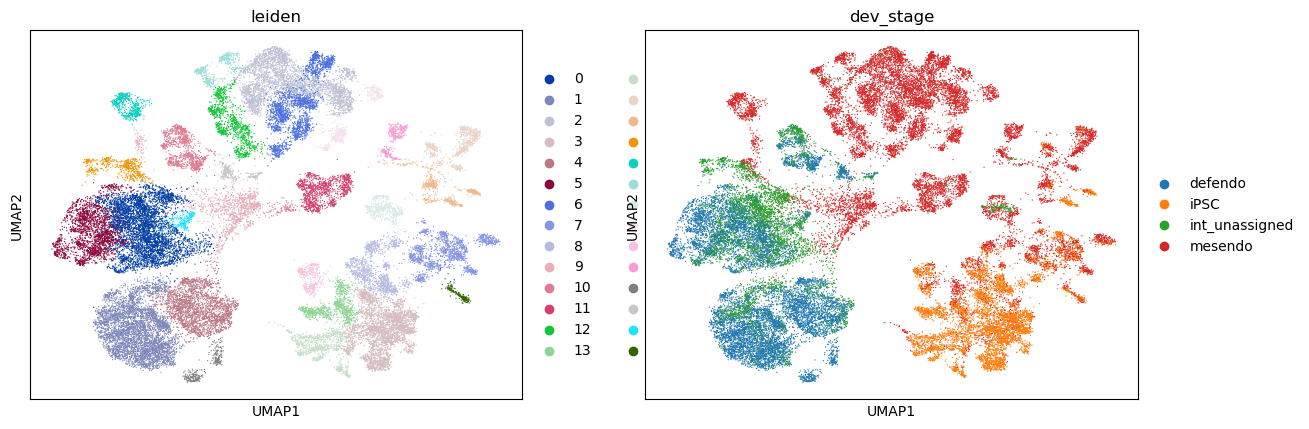

In [11]:
# Plot UMAP
sc.pl.umap(adata, color=['leiden', "dev_stage"])

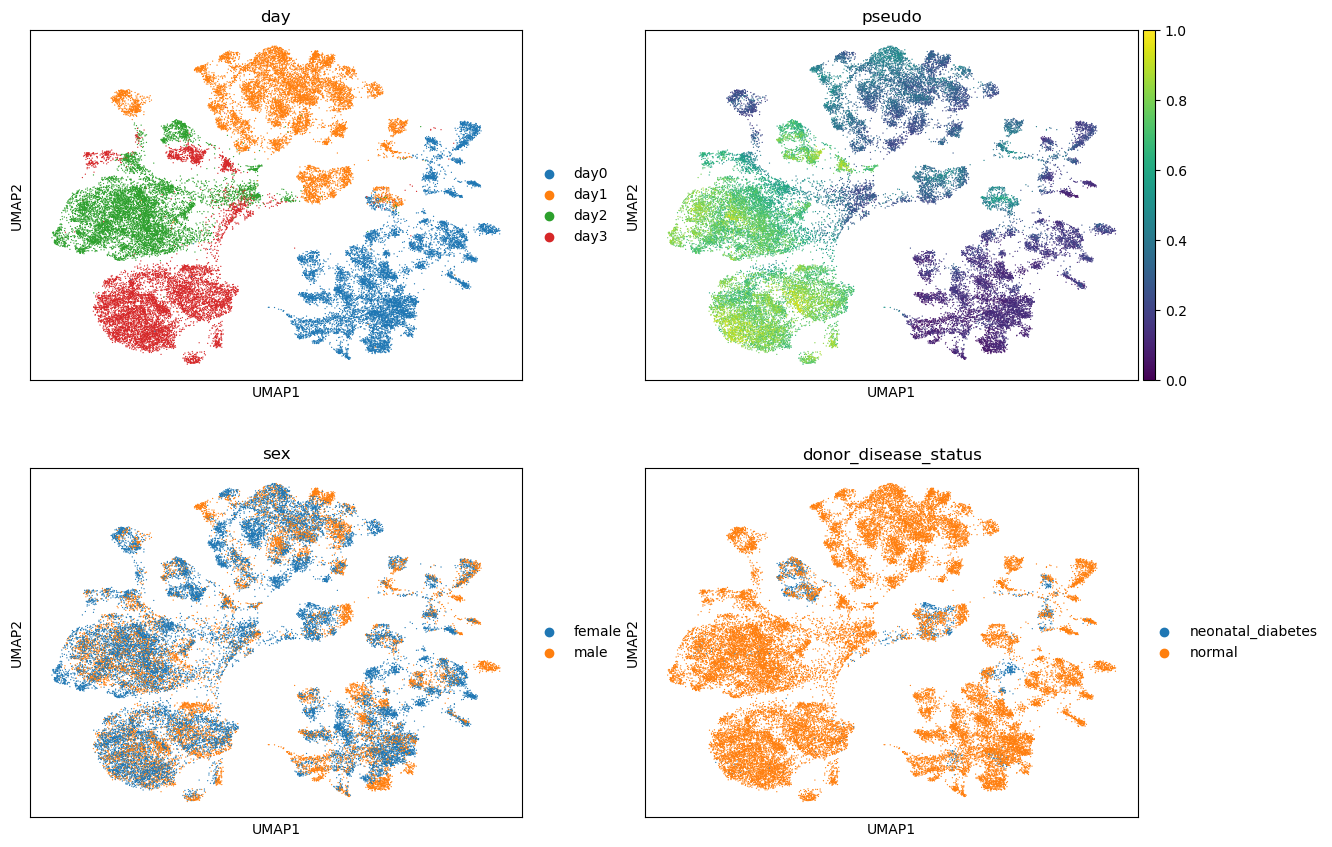

In [12]:
sc.pl.umap(adata, color=['day', 'pseudo', 'sex', 'donor_disease_status'], ncols=2)

In [13]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packa

categories: day0, day1, day2, etc.
var_group_labels: 0, 1, 2, etc.


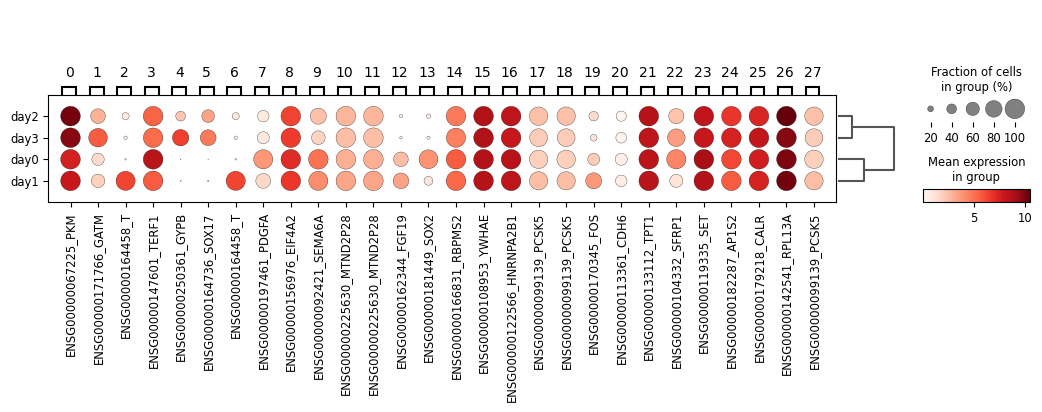

In [14]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=1, groupby="day")


In [15]:
# Save the AnnData object for future use in WD with today's date 
today = datetime.datetime.today().strftime('%Y-%m-%d')
adata.write(f"{WD}/gene_expression_{today}.h5ad")

In [17]:
print(f"The AnnData object has been saved to {WD}/gene_expression_{today}.h5ad")

The AnnData object has been saved to /gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/zenodo/gene_expression_2025-02-22.h5ad


In [16]:
# metadata_full.shape --> # 36044 in gene expression matrix as well but their cell names don't match 